### Exploratory Data Analysis for Research Question 3 
- To what extent are demographic characteristics particularly gender, associated with financial inclusion in Thailand, and have these disparities changed between 2021 and 2024?

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

sns.set(style="whitegrid", context="notebook") 
plt.rcParams['figure.dpi'] = 100 
pd.set_option('display.max_columns', 12)
pd.set_option('display.max_rows', 12)

rq3 = pd.read_csv("data_cleaned.csv")

In [3]:
rq3.head(5)

,wage_payment_method,no_account_family_member,debit_card_ownership,ever_had_mobile_money_account,survey_year,ever_had_bank_account,...,received_transfers,no_account_insufficient_funds,codes_found,gender,age_group,education_original
0,2.0,NaN,2.0,2.0,2021,NaN,...,1.0,NaN,False,Female,23_29,3.0
1,2.0,NaN,1.0,1.0,2021,NaN,...,1.0,NaN,False,Male,30_39,3.0
2,NaN,NaN,NaN,2.0,2021,NaN,...,1.0,NaN,False,Female,40_49,3.0
3,NaN,NaN,NaN,2.0,2021,NaN,...,1.0,NaN,False,Female,40_49,3.0
4,NaN,NaN,2.0,1.0,2021,NaN,...,1.0,NaN,False,Male,30_39,3.0


In [5]:
rq3.columns.tolist()

['wage_payment_method',
 'no_account_family_member',
 'debit_card_ownership',
 'ever_had_mobile_money_account',
 'survey_year',
 'ever_had_bank_account',
 'no_account_documentation',
 'borrowed_money',
 'saved_mobile_money',
 'female',
 'account_ownership',
 'credit_card_ownership',
 'received_goverment_transfer',
 'wages_bank_account',
 'mobile_money_transaction',
 'agriculture_payment_method',
 'mobile_money_activity',
 'no_account_distance',
 'age',
 'saved_bank',
 'education_level',
 'received_wages',
 'utility_payment',
 'any_digital_payment',
 'account_transaction_activity',
 'no_mobile_agents_far',
 'emergency_funds',
 'no_account_too_expensive',
 'sent_domestic_remittance_account',
 'merchantpay_dig',
 'store_money_account',
 'income_quintile',
 'utility_payment_cash',
 'agriculture_payment_account',
 'borrowed_from_family_friends',
 'financial_health_indicator',
 'borrowed_from_formal_bank',
 'mobile_money_send_recieve',
 'high_withdrawal_fee_wages',
 'received_acc_balance_inf

### Financial Inclusion Dimension

### Demographics & socioeconomics indicators

In [11]:
demographics = rq3[["age", "gender", "income_quintile", "education_level", "survey_year", "employment_status"]]

In [13]:
demographics.head()

,age,gender,income_quintile,education_level,survey_year,employment_status
0,27.0,Female,Q4,3.0,2021,1.0
1,30.0,Male,Q4,3.0,2021,1.0
2,45.0,Female,Q4,3.0,2021,1.0
3,45.0,Female,Q1 Lowest,3.0,2021,1.0
4,39.0,Male,Q4,3.0,2021,1.0


In [14]:
demographics["gender"].value_counts(normalize=True)*100

gender
Female    54.586019
Male      45.413981
Name: proportion, dtype: float64

In [ ]:
demographics["income_quintile"].value_counts(normalize=True)*100

income_quintile
Q5 Highest    26.623699
Q4            23.153198
Q3            17.600397
Q1 Lowest     16.955875
Q2            15.666832
Name: proportion, dtype: float64

### Age Distribution

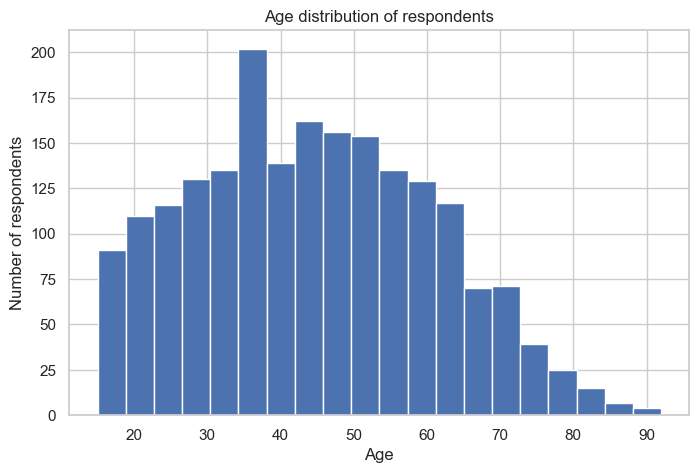

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.hist(demographics["age"].dropna(),bins=20)
plt.xlabel("Age")
plt.ylabel("Number of respondents")
plt.title("Age distribution of respondents")

plt.show()

### Gender Distribution

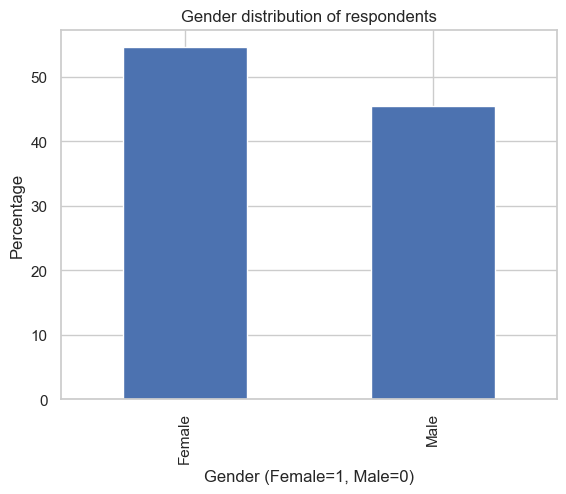

In [ ]:
gender_pct = (demographics["gender"].value_counts(normalize=True).mul(100))
gender_pct.plot(kind="bar")
plt.xlabel("Gender (Female=1, Male=0)")
plt.ylabel("Percentage")
plt.title("Gender distribution of respondents")

plt.show()

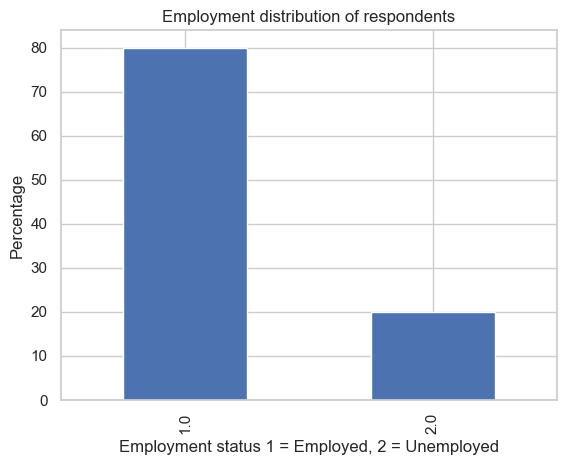

In [21]:
# Employment distribution of respondents
employment_pct = (demographics["employment_status"].value_counts(normalize=True).mul(100))
employment_pct.plot(kind="bar")
plt.xlabel("Employment status 1 = Employed, 2 = Unemployed")
plt.ylabel("Percentage")
plt.title("Employment distribution of respondents")

plt.show()

In [ ]:
df_health = rq3[rq3["account_usage"].isin([1, 2, 3, 4, 5, 6])].copy()

In [22]:
financial_vars = [
    "account_ownership",
    "financial_instituion_account",
    "mobile_money_account",
    "any_digital_payment",
    "account_usage",
    "saved_money",
    "borrowed_money"
]

In [23]:
for col in financial_vars:
    print(
        f"\n{col}")
    print(rq3[col].value_counts(normalize=True).mul(100))


account_ownership
account_ownership
1    94.843827
0     5.156173
Name: proportion, dtype: float64

financial_instituion_account
financial_instituion_account
1    94.199306
0     5.800694
Name: proportion, dtype: float64

mobile_money_account
mobile_money_account
1.0    51.611304
0.0    48.388696
Name: proportion, dtype: float64

any_digital_payment
any_digital_payment
1.0    88.844819
0.0    11.155181
Name: proportion, dtype: float64

account_usage
account_usage
1.0    60.949299
2.0    25.728155
3.0     8.360302
4.0     3.398058
6.0     1.024811
5.0     0.539374
Name: proportion, dtype: float64

saved_money
saved_money
1.0    68.071393
0.0    31.928607
Name: proportion, dtype: float64

borrowed_money
borrowed_money
1.0    54.090233
0.0    45.909767
Name: proportion, dtype: float64


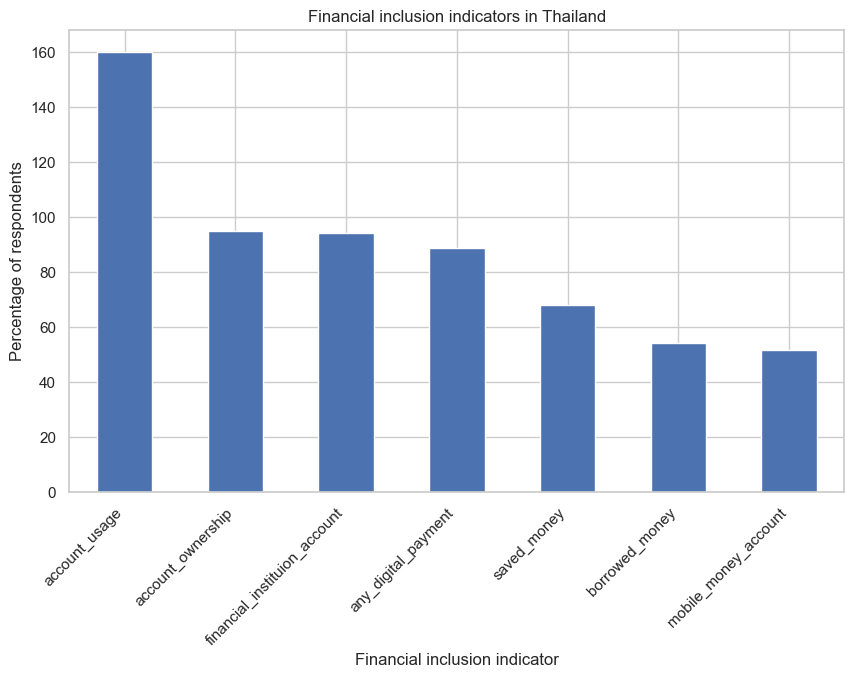

In [24]:
inclusion_rates = (rq3[financial_vars].mean().sort_values(ascending=False).mul(100))

inclusion_rates.plot(kind="bar",figsize=(10, 6))

plt.ylabel("Percentage of respondents")
plt.xlabel("Financial inclusion indicator")
plt.title("Financial inclusion indicators in Thailand")

plt.xticks(rotation=45, ha="right")
plt.show()

        account_ownership  financial_instituion_account  mobile_money_account  \
gender                                                                          
Female          94.277929                     93.642144             49.137148   
Male            95.524017                     94.868996             54.585153   

        any_digital_payment  account_usage  saved_money  borrowed_money  
gender                                                                   
Female            87.829246     162.800000    66.303361       53.678474  
Male              90.065502     156.557377    70.196507       54.585153  


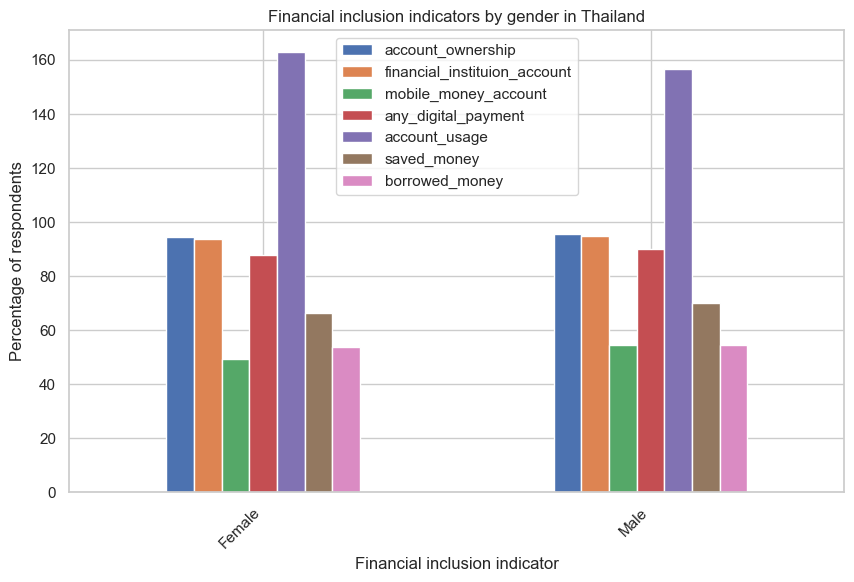

In [ ]:
## Gender inclusion 
gender_inclusion = (rq3.groupby("gender")[financial_vars].mean().mul(100))
print(gender_inclusion)
# show percentage variables
gender_inclusion.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Percentage of respondents")
plt.xlabel("Financial inclusion indicator")
plt.title("Financial inclusion indicators by gender in Thailand")
plt.xticks(rotation=45, ha="right")
plt.show()

### Access and Ownership

- Access and Ownership: Does the person have access to formal/digital financial infrastructure?

In [6]:
acc_own = rq3[["account_ownership", 
            "financial_instituion_account", 
            "mobile_money_account",
            "debit_card_ownership",
            "credit_card_ownership"]] 
acc_own.head()

,account_ownership,financial_instituion_account,mobile_money_account,debit_card_ownership,credit_card_ownership
0,1,1,1.0,2.0,1.0
1,1,1,1.0,1.0,1.0
2,1,1,1.0,NaN,1.0
3,1,1,1.0,NaN,1.0
4,1,1,0.0,2.0,1.0


### Usage

- Does the person actually use financial services?

In [7]:
acc_usage = rq3[["account_usage",
                "account_transaction_activity",
                "any_digital_payment",
                "mobile_money_activity",
                "mobile_money_usage",
                "mobile_money_transaction",
                "merchantpay_dig",
                "made_utility_payment"]]

### Saving and Borrowing 
- Can people use the financial system for saving and borrowing?

In [8]:
saving_borrow = rq3[["saved_money",
                    "saved_bank",
                    "saved_mobile_money",
                    "borrowed_money",
                    "borrowed_from_formal_bank",
                    "borrowed_from_family_friends",
                    "borrowed_from_savings_club"]]